In [ ]:
from pyscf import gto, scf
import numpy as np
from py_mods.src.SCF.CSRHF import CS_RHF
from py_mods.src.SCF.CSUHF import CS_UHF
from py_mods.src.SCF.plot_utilities import plot_map
from py_mods.src.SCF.external import RHF_context_from_pyscf, UHF_context_from_pyscf

In [ ]:
large_basis = '''
He    S
      5.285000E+02           0.000000E+00           9.400000E-04           0.000000E+00           0.000000E+00
      7.931000E+01           0.000000E+00           7.214000E-03           0.000000E+00           0.000000E+00
      1.805000E+01           0.000000E+00           3.597500E-02           0.000000E+00           0.000000E+00
      5.085000E+00           0.000000E+00           1.277820E-01           0.000000E+00           0.000000E+00
      1.609000E+00           1.000000E+00           3.084700E-01           0.000000E+00           0.000000E+00
      5.363000E-01           0.000000E+00           4.530520E-01           1.000000E+00           0.000000E+00
      1.833000E-01           0.000000E+00           2.388840E-01           0.000000E+00           1.000000E+00
He    S
      0.0481900              1.0000000
He    P
      5.994000E+00           1.000000E+00           0.000000E+00           0.000000E+00
      1.745000E+00           0.000000E+00           1.000000E+00           0.000000E+00
      5.600000E-01           0.000000E+00           0.000000E+00           1.000000E+00
He    P
      0.1626000              1.0000000
He    D
      4.299000E+00           1.000000E+00           0.000000E+00
      1.223000E+00           0.000000E+00           1.000000E+00
He    D
      0.3510000              1.0000000
He    F
      2.680000E+00           1.0000000
He    F
      0.6906000              1.0000000
END
'''

converged SCF energy = -2.85570466771043


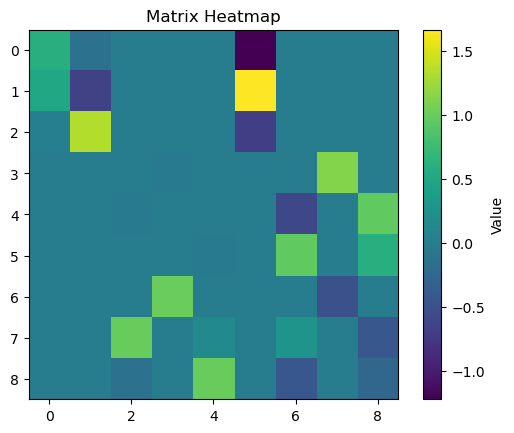

[ 1.11570909  0.52985164  0.83602037  0.98786265  1.11929226 -0.23473323
  0.19952048  0.62211635  0.85688335]


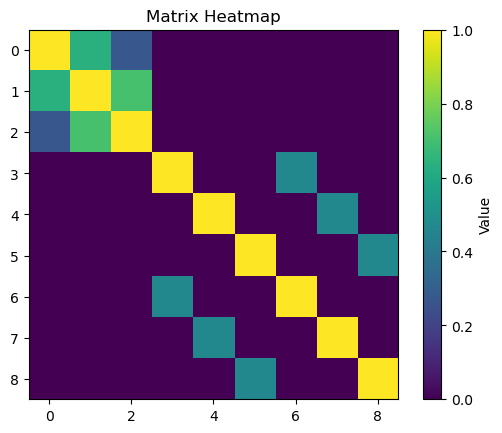

In [3]:
# pyscf data
pyscf_args = {
    'atom': 'He 0 0 0',
    'spin': 0,
    'charge': 0,
    'basis': 'aug-cc-pvdz',
}

mol = gto.M(**pyscf_args)
# mol.basis = {'He': gto.basis.parse(large_basis)}
# mol.build()

mf = scf.RHF(mol) 
e_He = mf.kernel()
e_elec = mf.energy_elec()

plot_map(mf.mo_coeff)
sum_cols = np.sum(mf.mo_coeff, axis=0)
print(sum_cols)
plot_map(mol.intor('int1e_ovlp'))
# mymp = mp.RMP2(mf).run() # this is UMP2

In [ ]:
# implementation and calculation
RHF_cxt = UHF_context_from_pyscf(**pyscf_args)
RHF_cxt.theta = 0.00
RHF_cxt.occupation = np.array([2,0])
RHF_cxt.threshold = 1E-14
RHF_res = CS_RHF(RHF_cxt)

C_munu = RHF_res.R_munu.real
F_MO = RHF_res.R_munu.real.T @ RHF_res.F_final.real @ RHF_res.R_munu.real
plot_map(F_MO)
plot_map(F_MO-np.diag(np.diagonal(F_MO)))
plot_map(C_munu)

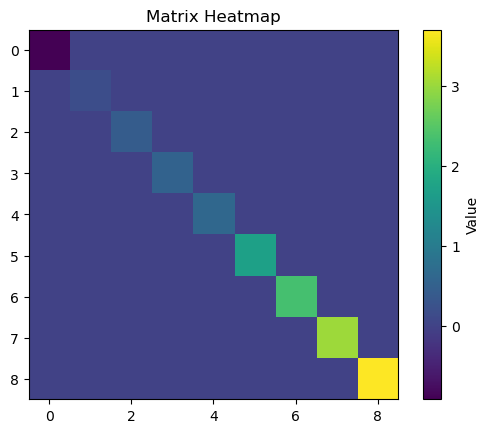

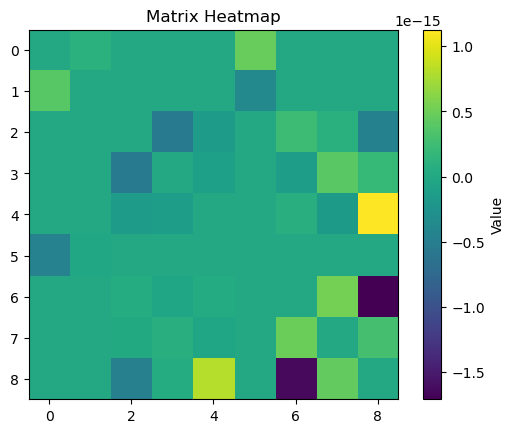

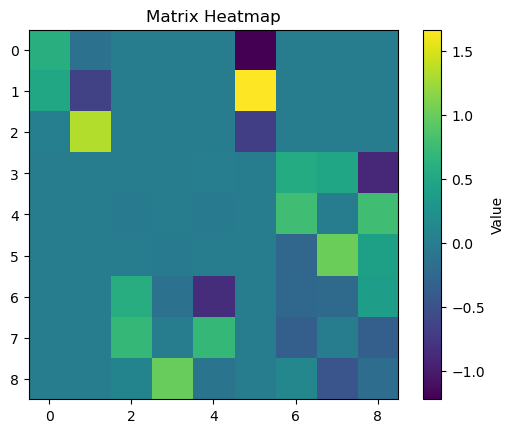

In [7]:
# implementation and calculation
RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
RHF_cxt.theta = 0.00
RHF_cxt.occupation = np.array([2,0])
RHF_cxt.threshold = 1E-14
RHF_res = CS_RHF(RHF_cxt)

C_munu = RHF_res.R_munu.real
F_MO = RHF_res.R_munu.real.T @ RHF_res.F_final.real @ RHF_res.R_munu.real
plot_map(F_MO)
plot_map(F_MO-np.diag(np.diagonal(F_MO)))
plot_map(C_munu)

In [5]:
print(RHF_res.e_orb.real-mf.mo_energy)

[-3.45231121e-09 -1.81065274e-10 -1.26542232e-09 -1.26542232e-09
 -1.26541932e-09 -3.22597704e-09 -4.53036941e-09 -4.53036986e-09
 -4.53036586e-09]


Which is not large, but however these energy differences might be enough to break the MP2. 

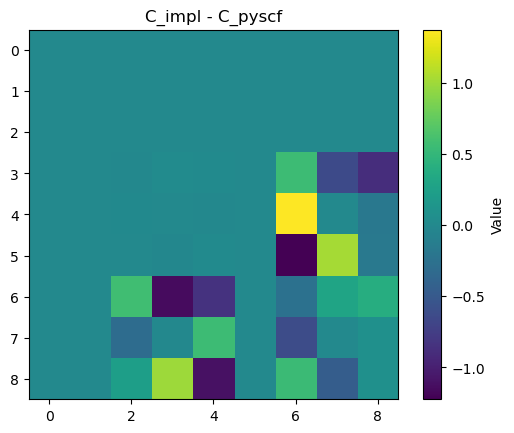

In [6]:
plot_map(C_munu - mf.mo_coeff, title='C_impl - C_pyscf')